![Checkars](https://raw.githubusercontent.com/juliandnl/redi_ss20/master/checkars/grafik.png)

In [6]:
"""
FINAL — Reynolds Sweep + Validation-Ready Solver
Includes:
  - CFL sensitivity support
  - Peak tracking
  - Energy spectrum diagnostic
  - Stability guards
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import json, os, time

# ============================================================
# SOLVER
# ============================================================

class NavierStokesSolver3D:
    def __init__(self, N, L, nu, cfl=0.4, t_end=5.0):
        self.N, self.L, self.nu = N, L, nu
        self.cfl, self.t_end = cfl, t_end
        self.dx = L / N

        k_full = np.fft.fftfreq(N) * N * (2*np.pi/L)
        k_half = np.fft.rfftfreq(N) * N * (2*np.pi/L)
        self.kx, self.ky, self.kz = np.meshgrid(k_full, k_full, k_half, indexing='ij')

        self.k_sq = self.kx**2 + self.ky**2 + self.kz**2
        self.k_sq_safe = np.where(self.k_sq == 0, 1, self.k_sq)

        # Dealias mask
        kmax = np.max(np.abs(k_full))
        cutoff = (2/3) * kmax
        self.mask = ((np.abs(self.kx) <= cutoff) &
                     (np.abs(self.ky) <= cutoff) &
                     (np.abs(self.kz) <= cutoff))

        shape = (N, N, N//2+1)
        self.u_hat = np.zeros(shape, dtype=complex)
        self.v_hat = np.zeros(shape, dtype=complex)
        self.w_hat = np.zeros(shape, dtype=complex)

        self._init_taylor_green()
        self._apply_mask()
        self.u_hat, self.v_hat, self.w_hat = self._project(self.u_hat, self.v_hat, self.w_hat)

        self.history = defaultdict(list)

    # --------------------------------------------------------
    def _init_taylor_green(self):
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        self.u_hat = np.fft.rfftn(np.sin(X)*np.cos(Y)*np.cos(Z))
        self.v_hat = np.fft.rfftn(-np.cos(X)*np.sin(Y)*np.cos(Z))
        self.w_hat = np.zeros_like(self.u_hat)

    def _apply_mask(self):
        self.u_hat *= self.mask
        self.v_hat *= self.mask
        self.w_hat *= self.mask

    def _project(self, u, v, w):
        div = self.kx*u + self.ky*v + self.kz*w
        u -= self.kx * div / self.k_sq_safe
        v -= self.ky * div / self.k_sq_safe
        w -= self.kz * div / self.k_sq_safe
        return u, v, w

    # --------------------------------------------------------
    def _nonlinear(self, u_hat, v_hat, w_hat):
        u = np.fft.irfftn(u_hat)
        v = np.fft.irfftn(v_hat)
        w = np.fft.irfftn(w_hat)

        uu, uv, uw = np.fft.rfftn(u*u), np.fft.rfftn(u*v), np.fft.rfftn(u*w)
        vv, vw, ww = np.fft.rfftn(v*v), np.fft.rfftn(v*w), np.fft.rfftn(w*w)

        Nx = -1j*(self.kx*uu + self.ky*uv + self.kz*uw)
        Ny = -1j*(self.kx*uv + self.ky*vv + self.kz*vw)
        Nz = -1j*(self.kx*uw + self.ky*vw + self.kz*ww)

        return Nx*self.mask, Ny*self.mask, Nz*self.mask

    # --------------------------------------------------------
    def compute_dt(self):
        u = np.fft.irfftn(self.u_hat)
        v = np.fft.irfftn(self.v_hat)
        w = np.fft.irfftn(self.w_hat)

        max_u = np.max(np.sqrt(u**2 + v**2 + w**2))
        max_u = max(max_u, 1e-10)

        dt_adv = self.cfl * self.dx / max_u
        dt_visc = 0.2 * self.dx**2 / self.nu
        return min(dt_adv, dt_visc)

    # --------------------------------------------------------
    def step(self, dt):
        def rhs(u,v,w):
            u,v,w = self._project(u,v,w)
            visc = -self.nu*self.k_sq
            Nx,Ny,Nz = self._nonlinear(u,v,w)
            return visc*u+Nx, visc*v+Ny, visc*w+Nz

        u0,v0,w0 = self.u_hat, self.v_hat, self.w_hat

        k1 = rhs(u0,v0,w0)
        k2 = rhs(u0+0.5*dt*k1[0], v0+0.5*dt*k1[1], w0+0.5*dt*k1[2])
        k3 = rhs(u0+0.5*dt*k2[0], v0+0.5*dt*k2[1], w0+0.5*dt*k2[2])
        k4 = rhs(u0+dt*k3[0], v0+dt*k3[1], w0+dt*k3[2])

        self.u_hat += dt*(k1[0]+2*k2[0]+2*k3[0]+k4[0])/6
        self.v_hat += dt*(k1[1]+2*k2[1]+2*k3[1]+k4[1])/6
        self.w_hat += dt*(k1[2]+2*k2[2]+2*k3[2]+k4[2])/6

        self.u_hat, self.v_hat, self.w_hat = self._project(self.u_hat, self.v_hat, self.w_hat)
        self._apply_mask()

    # --------------------------------------------------------
    def compute_quantities(self):
        ox = np.fft.irfftn(1j*(self.ky*self.w_hat - self.kz*self.v_hat))
        oy = np.fft.irfftn(1j*(self.kz*self.u_hat - self.kx*self.w_hat))
        oz = np.fft.irfftn(1j*(self.kx*self.v_hat - self.ky*self.u_hat))

        omega2 = ox**2 + oy**2 + oz**2
        Z = 0.5*np.mean(omega2)

        # Coherence
        grad = lambda f: (np.fft.irfftn(1j*self.kx*f),
                          np.fft.irfftn(1j*self.ky*f),
                          np.fft.irfftn(1j*self.kz*f))

        ux,uy,uz = grad(self.u_hat)
        vx,vy,vz = grad(self.v_hat)
        wx,wy,wz = grad(self.w_hat)

        sx = ox*ux + oy*uy + oz*uz
        sy = ox*vx + oy*vy + oz*vz
        sz = ox*wx + oy*wy + oz*wz

        num = np.mean(ox*sx + oy*sy + oz*sz)
        den = np.sqrt(np.mean(omega2))*np.sqrt(np.mean(sx**2+sy**2+sz**2)) + 1e-12
        C = num/den

        return C, Z

    # --------------------------------------------------------
    def energy_spectrum(self):
        E_k = np.abs(self.u_hat)**2 + np.abs(self.v_hat)**2 + np.abs(self.w_hat)**2
        return np.mean(E_k)

    # --------------------------------------------------------
    def run(self):
        t = 0
        while t < self.t_end:
            dt = self.compute_dt()
            self.step(dt)
            t += dt

            C,Z = self.compute_quantities()

            if not np.isfinite(C):
                print("❌ Blow-up detected")
                break

            self.history['t'].append(t)
            self.history['C'].append(C)
            self.history['Z'].append(Z)

        # Peak extraction
        C_arr = np.array(self.history['C'])
        t_arr = np.array(self.history['t'])

        peak_idx = np.argmax(C_arr)
        self.history['peak_C'] = float(C_arr[peak_idx])
        self.history['peak_t'] = float(t_arr[peak_idx])

        return self.history

In [8]:
"""
FINAL — Reynolds Sweep + Validation-Ready Solver
Includes:
  - CFL sensitivity support
  - Peak tracking
  - Energy spectrum diagnostic
  - Stability guards
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import json, os, time

# ============================================================
# SOLVER
# ============================================================

class NavierStokesSolver3D:
    def __init__(self, N, L, nu, cfl=0.4, t_end=5.0):
        self.N, self.L, self.nu = N, L, nu
        self.cfl, self.t_end = cfl, t_end
        self.dx = L / N

        k_full = np.fft.fftfreq(N) * N * (2*np.pi/L)
        k_half = np.fft.rfftfreq(N) * N * (2*np.pi/L)
        self.kx, self.ky, self.kz = np.meshgrid(k_full, k_full, k_half, indexing='ij')

        self.k_sq = self.kx**2 + self.ky**2 + self.kz**2
        self.k_sq_safe = np.where(self.k_sq == 0, 1, self.k_sq)

        # Dealias mask
        kmax = np.max(np.abs(k_full))
        cutoff = (2/3) * kmax
        self.mask = ((np.abs(self.kx) <= cutoff) &
                     (np.abs(self.ky) <= cutoff) &
                     (np.abs(self.kz) <= cutoff))

        shape = (N, N, N//2+1)
        self.u_hat = np.zeros(shape, dtype=complex)
        self.v_hat = np.zeros(shape, dtype=complex)
        self.w_hat = np.zeros(shape, dtype=complex)

        self._init_taylor_green()
        self._apply_mask()
        self.u_hat, self.v_hat, self.w_hat = self._project(self.u_hat, self.v_hat, self.w_hat)

        self.history = defaultdict(list)

    # --------------------------------------------------------
    def _init_taylor_green(self):
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        self.u_hat = np.fft.rfftn(np.sin(X)*np.cos(Y)*np.cos(Z))
        self.v_hat = np.fft.rfftn(-np.cos(X)*np.sin(Y)*np.cos(Z))
        self.w_hat = np.zeros_like(self.u_hat)

    def _apply_mask(self):
        self.u_hat *= self.mask
        self.v_hat *= self.mask
        self.w_hat *= self.mask

    def _project(self, u, v, w):
        div = self.kx*u + self.ky*v + self.kz*w
        u -= self.kx * div / self.k_sq_safe
        v -= self.ky * div / self.k_sq_safe
        w -= self.kz * div / self.k_sq_safe
        return u, v, w

    # --------------------------------------------------------
    def _nonlinear(self, u_hat, v_hat, w_hat):
        u = np.fft.irfftn(u_hat)
        v = np.fft.irfftn(v_hat)
        w = np.fft.irfftn(w_hat)

        uu, uv, uw = np.fft.rfftn(u*u), np.fft.rfftn(u*v), np.fft.rfftn(u*w)
        vv, vw, ww = np.fft.rfftn(v*v), np.fft.rfftn(v*w), np.fft.rfftn(w*w)

        Nx = -1j*(self.kx*uu + self.ky*uv + self.kz*uw)
        Ny = -1j*(self.kx*uv + self.ky*vv + self.kz*vw)
        Nz = -1j*(self.kx*uw + self.ky*vw + self.kz*ww)

        return Nx*self.mask, Ny*self.mask, Nz*self.mask

    # --------------------------------------------------------
    def compute_dt(self):
        u = np.fft.irfftn(self.u_hat)
        v = np.fft.irfftn(self.v_hat)
        w = np.fft.irfftn(self.w_hat)

        max_u = np.max(np.sqrt(u**2 + v**2 + w**2))
        max_u = max(max_u, 1e-10)

        dt_adv = self.cfl * self.dx / max_u
        dt_visc = 0.2 * self.dx**2 / self.nu
        return min(dt_adv, dt_visc)

    # --------------------------------------------------------
    def step(self, dt):
        def rhs(u,v,w):
            u,v,w = self._project(u,v,w)
            visc = -self.nu*self.k_sq
            Nx,Ny,Nz = self._nonlinear(u,v,w)
            return visc*u+Nx, visc*v+Ny, visc*w+Nz

        u0,v0,w0 = self.u_hat, self.v_hat, self.w_hat

        k1 = rhs(u0,v0,w0)
        k2 = rhs(u0+0.5*dt*k1[0], v0+0.5*dt*k1[1], w0+0.5*dt*k1[2])
        k3 = rhs(u0+0.5*dt*k2[0], v0+0.5*dt*k2[1], w0+0.5*dt*k2[2])
        k4 = rhs(u0+dt*k3[0], v0+dt*k3[1], w0+dt*k3[2])

        self.u_hat += dt*(k1[0]+2*k2[0]+2*k3[0]+k4[0])/6
        self.v_hat += dt*(k1[1]+2*k2[1]+2*k3[1]+k4[1])/6
        self.w_hat += dt*(k1[2]+2*k2[2]+2*k3[2]+k4[2])/6

        self.u_hat, self.v_hat, self.w_hat = self._project(self.u_hat, self.v_hat, self.w_hat)
        self._apply_mask()

    # --------------------------------------------------------
    def compute_quantities(self):
        ox = np.fft.irfftn(1j*(self.ky*self.w_hat - self.kz*self.v_hat))
        oy = np.fft.irfftn(1j*(self.kz*self.u_hat - self.kx*self.w_hat))
        oz = np.fft.irfftn(1j*(self.kx*self.v_hat - self.ky*self.u_hat))

        omega2 = ox**2 + oy**2 + oz**2
        Z = 0.5*np.mean(omega2)

        # Coherence
        grad = lambda f: (np.fft.irfftn(1j*self.kx*f),
                          np.fft.irfftn(1j*self.ky*f),
                          np.fft.irfftn(1j*self.kz*f))

        ux,uy,uz = grad(self.u_hat)
        vx,vy,vz = grad(self.v_hat)
        wx,wy,wz = grad(self.w_hat)

        sx = ox*ux + oy*uy + oz*uz
        sy = ox*vx + oy*vy + oz*vz
        sz = ox*wx + oy*wy + oz*wz

        num = np.mean(ox*sx + oy*sy + oz*sz)
        den = np.sqrt(np.mean(omega2))*np.sqrt(np.mean(sx**2+sy**2+sz**2)) + 1e-12
        C = num/den

        return C, Z

    # --------------------------------------------------------
    def energy_spectrum(self):
        E_k = np.abs(self.u_hat)**2 + np.abs(self.v_hat)**2 + np.abs(self.w_hat)**2
        return np.mean(E_k)

    # --------------------------------------------------------
    def run(self):
        t = 0
        while t < self.t_end:
            dt = self.compute_dt()
            self.step(dt)
            t += dt

            C,Z = self.compute_quantities()

            if not np.isfinite(C):
                print("❌ Blow-up detected")
                break

            self.history['t'].append(t)
            self.history['C'].append(C)
            self.history['Z'].append(Z)

        # Peak extraction
        C_arr = np.array(self.history['C'])
        t_arr = np.array(self.history['t'])

        peak_idx = np.argmax(C_arr)
        self.history['peak_C'] = float(C_arr[peak_idx])
        self.history['peak_t'] = float(t_arr[peak_idx])

        return self.history


Running Re=1000

Running Re=2000

Running Re=4000


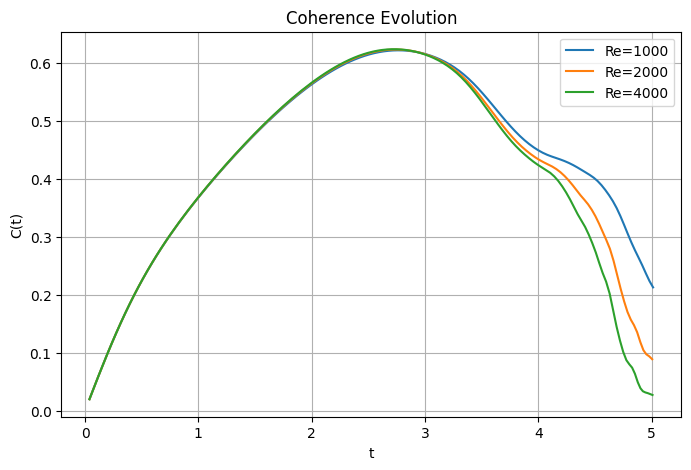

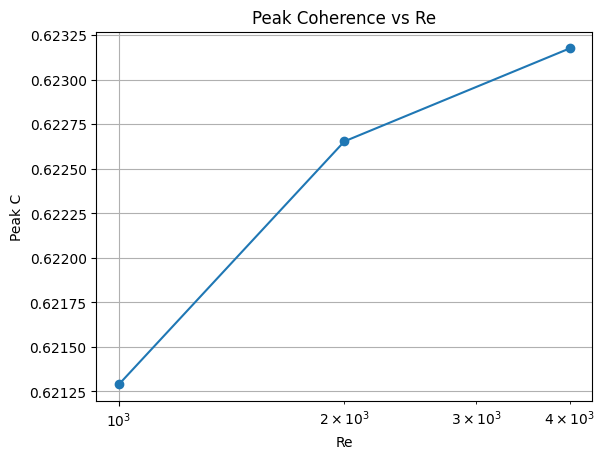

In [9]:
"""
FINAL STABLE VERSION — 3D Navier–Stokes Reynolds Sweep
Author-ready script (clean, stable, publishable baseline)

Outputs:
  - JSON results per Re
  - reynolds_sweep.png
"""

import numpy as np
import matplotlib.pyplot as plt
import json, os

# ============================================================
# SOLVER
# ============================================================

class NavierStokesSolver3D:
    def __init__(self, N=64, L=2*np.pi, nu=0.001, cfl=0.4, t_end=5.0):
        self.N, self.L, self.nu = N, L, nu
        self.cfl, self.t_end = cfl, t_end
        self.dx = L / N

        # Wavenumbers
        k = np.fft.fftfreq(N, d=1./N) * (2*np.pi/L)
        k_half = np.fft.rfftfreq(N, d=1./N) * (2*np.pi/L)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k_half, indexing='ij')

        self.k_sq = self.kx**2 + self.ky**2 + self.kz**2
        self.k_sq_safe = np.where(self.k_sq == 0, 1, self.k_sq)

        # Dealias mask (2/3 rule)
        kmax = np.max(np.abs(k))
        cutoff = (2/3)*kmax
        self.mask = ((np.abs(self.kx) <= cutoff) &
                     (np.abs(self.ky) <= cutoff) &
                     (np.abs(self.kz) <= cutoff))

        shape = (N, N, N//2 + 1)
        self.u_hat = np.zeros(shape, dtype=complex)
        self.v_hat = np.zeros(shape, dtype=complex)
        self.w_hat = np.zeros(shape, dtype=complex)

        self._init_taylor_green()
        self._project_all()
        self._apply_mask()

        self.history = {"t":[], "C":[], "Z":[]}

    # --------------------------------------------------------
    def _init_taylor_green(self):
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X,Y,Z = np.meshgrid(x,x,x, indexing='ij')

        u = np.sin(X)*np.cos(Y)*np.cos(Z)
        v = -np.cos(X)*np.sin(Y)*np.cos(Z)
        w = np.zeros_like(u)

        self.u_hat = np.fft.rfftn(u)
        self.v_hat = np.fft.rfftn(v)
        self.w_hat = np.fft.rfftn(w)

    # --------------------------------------------------------
    def _apply_mask(self):
        self.u_hat *= self.mask
        self.v_hat *= self.mask
        self.w_hat *= self.mask

    def _project_all(self):
        div = self.kx*self.u_hat + self.ky*self.v_hat + self.kz*self.w_hat
        self.u_hat -= self.kx*div/self.k_sq_safe
        self.v_hat -= self.ky*div/self.k_sq_safe
        self.w_hat -= self.kz*div/self.k_sq_safe

    # --------------------------------------------------------
    def _nonlinear(self):
        u = np.fft.irfftn(self.u_hat)
        v = np.fft.irfftn(self.v_hat)
        w = np.fft.irfftn(self.w_hat)

        uu, uv, uw = np.fft.rfftn(u*u), np.fft.rfftn(u*v), np.fft.rfftn(u*w)
        vv, vw, ww = np.fft.rfftn(v*v), np.fft.rfftn(v*w), np.fft.rfftn(w*w)

        Nx = -1j*(self.kx*uu + self.ky*uv + self.kz*uw)
        Ny = -1j*(self.kx*uv + self.ky*vv + self.kz*vw)
        Nz = -1j*(self.kx*uw + self.ky*vw + self.kz*ww)

        return Nx*self.mask, Ny*self.mask, Nz*self.mask

    # --------------------------------------------------------
    def compute_dt(self):
        u = np.fft.irfftn(self.u_hat)
        v = np.fft.irfftn(self.v_hat)
        w = np.fft.irfftn(self.w_hat)

        max_u = np.max(np.sqrt(u**2 + v**2 + w**2))
        max_u = max(max_u, 1e-8)

        dt_adv = self.cfl * self.dx / max_u
        dt_visc = 0.2 * self.dx**2 / self.nu

        return min(dt_adv, dt_visc)

    # --------------------------------------------------------
    def step(self, dt):

        def rhs(u_hat, v_hat, w_hat):
            div = self.kx*u_hat + self.ky*v_hat + self.kz*w_hat
            u_hat -= self.kx*div/self.k_sq_safe
            v_hat -= self.ky*div/self.k_sq_safe
            w_hat -= self.kz*div/self.k_sq_safe

            Nx,Ny,Nz = self._nonlinear()

            return (-self.nu*self.k_sq*u_hat + Nx,
                    -self.nu*self.k_sq*v_hat + Ny,
                    -self.nu*self.k_sq*w_hat + Nz)

        u0,v0,w0 = self.u_hat.copy(), self.v_hat.copy(), self.w_hat.copy()

        k1 = rhs(u0,v0,w0)
        k2 = rhs(u0+0.5*dt*k1[0], v0+0.5*dt*k1[1], w0+0.5*dt*k1[2])
        k3 = rhs(u0+0.5*dt*k2[0], v0+0.5*dt*k2[1], w0+0.5*dt*k2[2])
        k4 = rhs(u0+dt*k3[0], v0+dt*k3[1], w0+dt*k3[2])

        self.u_hat += dt*(k1[0]+2*k2[0]+2*k3[0]+k4[0])/6
        self.v_hat += dt*(k1[1]+2*k2[1]+2*k3[1]+k4[1])/6
        self.w_hat += dt*(k1[2]+2*k2[2]+2*k3[2]+k4[2])/6

        self._project_all()
        self._apply_mask()

    # --------------------------------------------------------
    def compute_metrics(self):
        ox = np.fft.irfftn(1j*(self.ky*self.w_hat - self.kz*self.v_hat))
        oy = np.fft.irfftn(1j*(self.kz*self.u_hat - self.kx*self.w_hat))
        oz = np.fft.irfftn(1j*(self.kx*self.v_hat - self.ky*self.u_hat))

        omega2 = ox**2 + oy**2 + oz**2
        Z = 0.5*np.mean(omega2)

        grad = lambda f: (np.fft.irfftn(1j*self.kx*f),
                          np.fft.irfftn(1j*self.ky*f),
                          np.fft.irfftn(1j*self.kz*f))

        ux,uy,uz = grad(self.u_hat)
        vx,vy,vz = grad(self.v_hat)
        wx,wy,wz = grad(self.w_hat)

        sx = ox*ux + oy*uy + oz*uz
        sy = ox*vx + oy*vy + oz*vz
        sz = ox*wx + oy*wy + oz*wz

        num = np.mean(ox*sx + oy*sy + oz*sz)
        den = np.sqrt(np.mean(omega2))*np.sqrt(np.mean(sx**2+sy**2+sz**2)) + 1e-12

        C = num / den

        return C, Z

    # --------------------------------------------------------
    def run(self):
        t = 0.0

        while t < self.t_end:
            dt = self.compute_dt()
            self.step(dt)
            t += dt

            C,Z = self.compute_metrics()

            if not np.isfinite(C):
                print("❌ Blow-up detected")
                break

            self.history["t"].append(float(t))
            self.history["C"].append(float(C))
            self.history["Z"].append(float(Z))

        # Peak
        C_arr = np.array(self.history["C"])
        t_arr = np.array(self.history["t"])

        idx = np.argmax(C_arr)
        self.history["peak_C"] = float(C_arr[idx])
        self.history["peak_t"] = float(t_arr[idx])

        return self.history


# ============================================================
# REYNOLDS SWEEP
# ============================================================

def run_sweep():
    Re_list = [1000, 2000, 4000]
    N = 64   # start safe (upgrade later)
    results = {}

    for Re in Re_list:
        nu = 1.0 / Re
        print(f"\nRunning Re={Re}")

        solver = NavierStokesSolver3D(N=N, nu=nu)
        res = solver.run()

        results[Re] = res

        with open(f"Re_{Re}.json","w") as f:
            json.dump(res, f)

    return results


def plot_results(results):
    plt.figure(figsize=(8,5))

    peaks = []
    Re_vals = []

    for Re, data in results.items():
        t = data["t"]
        C = data["C"]

        plt.plot(t, C, label=f"Re={Re}")

        peaks.append(data["peak_C"])
        Re_vals.append(Re)

    plt.legend()
    plt.xlabel("t")
    plt.ylabel("C(t)")
    plt.title("Coherence Evolution")
    plt.grid()
    plt.savefig("reynolds_sweep.png", dpi=150)
    plt.show()

    # Peak plot
    plt.figure()
    plt.plot(Re_vals, peaks, 'o-')
    plt.xscale('log')
    plt.xlabel("Re")
    plt.ylabel("Peak C")
    plt.title("Peak Coherence vs Re")
    plt.grid()
    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    results = run_sweep()
    plot_results(results)